In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

sns.set_style('whitegrid')

In [2]:
vendas = pd.read_csv('vendas_supermercado_com_cliente.csv')
vendas.head()

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
0,2023-01-01,Maçãs,Alimentos Frescos,16.46,10,0.0,164.60,49,2715.61
1,2023-01-01,Bananas,Alimentos Frescos,2.39,4,0.0,9.56,29,2280.15
2,2023-01-01,Laranjas,Alimentos Frescos,8.38,5,0.0,41.90,67,4419.56
3,2023-01-01,Tomates,Alimentos Frescos,2.03,15,0.0,30.45,29,3809.17
4,2023-01-01,Alface,Alimentos Frescos,37.14,14,0.0,519.96,24,1013.42


In [3]:
vendas.tail()

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
20070,2023-12-31,Produtos de higiene para pets,Pet Shop,26.62,15,0.21,315.4470,39,2475.82
20071,2023-12-31,Panelas,Utilidades Domésticas,33.00,19,0.15,532.9500,25,4766.49
20072,2023-12-31,Talheres,Utilidades Domésticas,27.60,12,0.29,235.1520,65,3367.68
20073,2023-12-31,Copos,Utilidades Domésticas,15.35,13,0.25,149.6625,42,3823.50
20074,2023-12-31,"Produtos descartáveis (pratos, copos, talheres)",Utilidades Domésticas,32.06,6,0.11,171.2004,59,3303.47


In [4]:
vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20075 entries, 0 to 20074
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Data         20075 non-null  object 
 1   Produto      20075 non-null  object 
 2   Categoria    20075 non-null  object 
 3   Preço        20075 non-null  float64
 4   Quantidade   20075 non-null  int64  
 5   Desconto     20075 non-null  float64
 6   Total_Venda  20075 non-null  float64
 7   Idade        20075 non-null  int64  
 8   Renda        20075 non-null  float64
dtypes: float64(4), int64(2), object(3)
memory usage: 1.4+ MB


In [5]:
vendas.describe(include='all')

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
count,20075,20075,20075,20075.000000,20075.000000,20075.000000,20075.000000,20075.000000,20075.000000
unique,365,55,9,NaN,NaN,NaN,NaN,NaN,NaN
top,2023-01-01,Maçãs,Alimentos Frescos,NaN,NaN,NaN,NaN,NaN,NaN
freq,55,365,5475,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,25.577109,10.007671,0.039760,245.901736,45.992827,2999.034265
std,NaN,NaN,NaN,14.115988,5.488450,0.085011,207.773694,16.482103,1159.717376
min,NaN,NaN,NaN,1.000000,1.000000,0.000000,0.910200,18.000000,1000.380000
25%,NaN,NaN,NaN,13.260000,5.000000,0.000000,75.604500,32.000000,1993.625000
50%,NaN,NaN,NaN,25.660000,10.000000,0.000000,186.320000,46.000000,2998.830000
75%,NaN,NaN,NaN,37.770000,15.000000,0.000000,370.040000,60.000000,4007.675000


## Pre-processamento

In [6]:
# Converter Data para datetime
vendas['Data'] = pd.to_datetime(vendas['Data'])

# Criar coluna Mes
vendas['Mes'] = vendas['Data'].dt.month

# Criar coluna Dia da Semana
vendas['Dia_Semana'] = vendas['Data'].dt.day_name()

# Criar coluna Faixa Etaria
def faixa_etaria(idade):
    if idade <= 35:
        return 'Jovem'
    elif idade <= 59:
        return 'Adulto'
    else:
        return 'Idoso'

vendas['Faixa_Etaria'] = vendas['Idade'].apply(faixa_etaria)

vendas.head()

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda,Mes,Dia_Semana,Faixa_Etaria
0,2023-01-01,Maçãs,Alimentos Frescos,16.46,10,0.0,164.60,49,2715.61,1,Sunday,Adulto
1,2023-01-01,Bananas,Alimentos Frescos,2.39,4,0.0,9.56,29,2280.15,1,Sunday,Jovem
2,2023-01-01,Laranjas,Alimentos Frescos,8.38,5,0.0,41.90,67,4419.56,1,Sunday,Idoso
3,2023-01-01,Tomates,Alimentos Frescos,2.03,15,0.0,30.45,29,3809.17,1,Sunday,Jovem
4,2023-01-01,Alface,Alimentos Frescos,37.14,14,0.0,519.96,24,1013.42,1,Sunday,Jovem


## Pergunta 1
Quais foram as categorias de produtos mais vendidos e em quais meses eles tiveram o maior pico de vendas?

In [7]:
# Categorias mais vendidas
total_por_categoria = vendas.groupby('Categoria')['Total_Venda'].sum()
total_por_categoria = total_por_categoria.sort_values(ascending=False)
print(total_por_categoria)

Categoria
Alimentos Frescos              1.365309e+06
Produtos de Mercearia          5.296536e+05
Laticínios e Ovos              4.599605e+05
Bebidas                        4.543942e+05
Produtos de Limpeza            4.475459e+05
Pet Shop                       4.403316e+05
Produtos de Higiene Pessoal    4.400395e+05
Congelados                     4.397201e+05
Utilidades Domésticas          3.595226e+05
Name: Total_Venda, dtype: float64


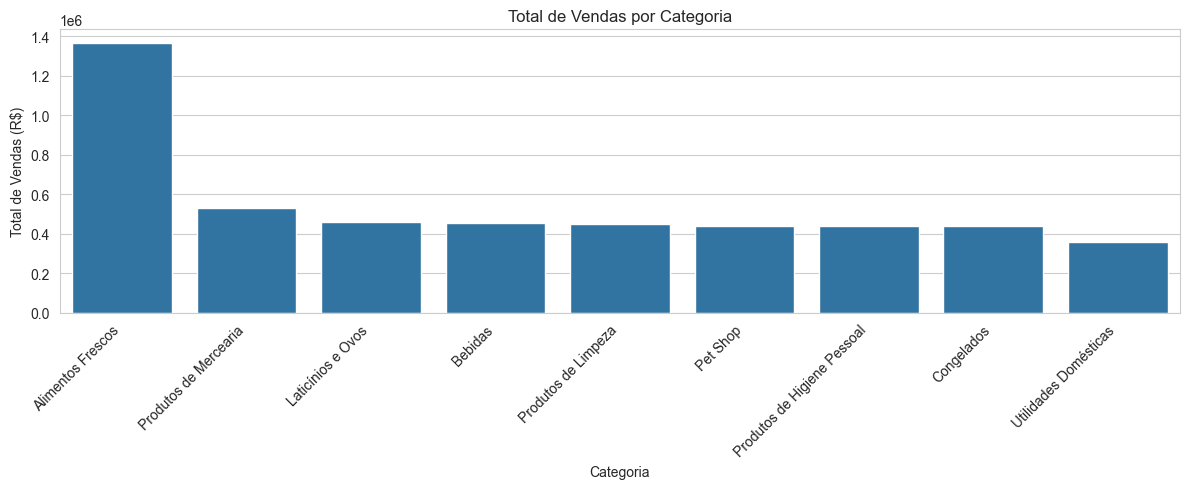

In [8]:
# Grafico de barras - total de vendas por categoria
df_cat = total_por_categoria.reset_index()
df_cat.columns = ['Categoria', 'Total_Vendas']

plt.figure(figsize=(12, 5))
sns.barplot(x='Categoria', y='Total_Vendas', data=df_cat)
plt.title('Total de Vendas por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Total de Vendas (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [9]:
# Pico de vendas por categoria e mes
vendas_por_mes = vendas.groupby(['Categoria', 'Mes'])['Total_Venda'].sum().reset_index()

for categoria in vendas['Categoria'].unique():
    df_cat = vendas_por_mes[vendas_por_mes['Categoria'] == categoria]
    df_cat = df_cat.sort_values('Total_Venda', ascending=False)
    mes_pico = df_cat.iloc[0]['Mes']
    total_pico = df_cat.iloc[0]['Total_Venda']
    print(f'{categoria}: mes {int(mes_pico)} | total R$ {total_pico:.2f}')

Alimentos Frescos: mes 3 | total R$ 129103.45
Produtos de Mercearia: mes 9 | total R$ 48192.29
Laticínios e Ovos: mes 10 | total R$ 43440.80
Bebidas: mes 1 | total R$ 47415.71
Produtos de Limpeza: mes 7 | total R$ 42358.75
Produtos de Higiene Pessoal: mes 7 | total R$ 42213.35
Congelados: mes 10 | total R$ 40418.34
Pet Shop: mes 1 | total R$ 40577.29
Utilidades Domésticas: mes 7 | total R$ 36674.81


## Pergunta 2
Qual a média de vendas diárias por categoria de produto?

In [8]:
# Total de vendas por dia e categoria
vendas_dia_cat = vendas.groupby(['Data', 'Categoria'])['Total_Venda'].sum().reset_index()

# Media diaria por categoria
media_diaria = vendas_dia_cat.groupby('Categoria')['Total_Venda'].mean()
media_diaria = media_diaria.sort_values(ascending=False).round(2)
print(media_diaria)

Categoria
Alimentos Frescos              3740.57
Produtos de Mercearia          1451.11
Laticínios e Ovos              1260.17
Bebidas                        1244.92
Produtos de Limpeza            1226.15
Pet Shop                       1206.39
Produtos de Higiene Pessoal    1205.59
Congelados                     1204.71
Utilidades Domésticas           984.99
Name: Total_Venda, dtype: float64


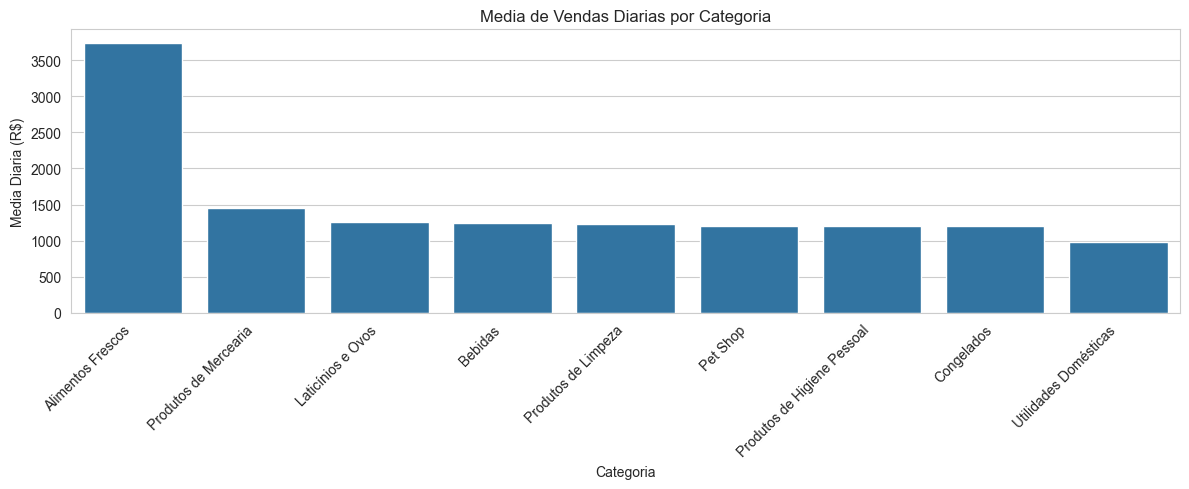

In [11]:
# Grafico de barras - media diaria por categoria
df_media = media_diaria.reset_index()
df_media.columns = ['Categoria', 'Media_Diaria']

plt.figure(figsize=(12, 5))
sns.barplot(x='Categoria', y='Media_Diaria', data=df_media)
plt.title('Media de Vendas Diarias por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Media Diaria (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Pergunta 3
Quais produtos apresentam a maior sazonalidade nas vendas?

In [9]:
# Total de vendas por produto e mes
prod_mes = vendas.groupby(['Produto', 'Mes'])['Total_Venda'].sum().reset_index()

# Desvio padrao = o quanto o produto varia entre os meses
variacao = prod_mes.groupby('Produto')['Total_Venda'].std()
variacao = variacao.sort_values(ascending=False).round(2)

print('Top 10 produtos com maior variacao mensal (mais sazonais):')
print(variacao.head(10))

Top 10 produtos com maior variacao mensal (mais sazonais):
Produto
Sucos                                              1751.82
Atum                                               1734.46
Tomates                                            1708.07
Vinhos                                             1689.40
Produtos descartáveis (pratos, copos, talheres)    1662.65
Refrigerantes                                      1661.96
Croissants                                         1629.43
Alface                                             1575.42
Cervejas                                           1530.24
Carne bovina                                       1499.49
Name: Total_Venda, dtype: float64


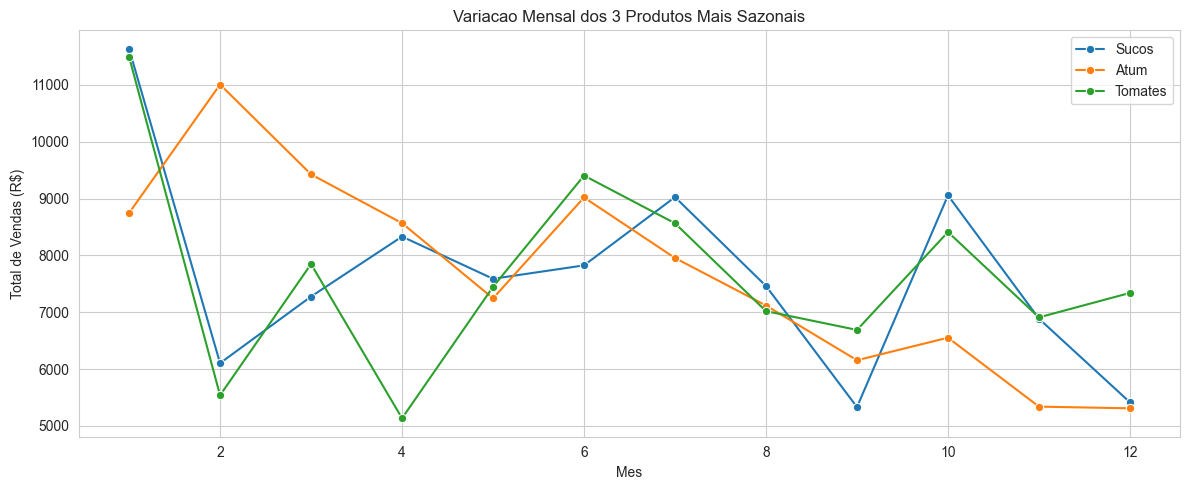

In [10]:
# Grafico de linha - evolucao mensal dos 3 produtos mais sazonais
top3 = variacao.head(3).index.tolist()
dados_top3 = prod_mes[prod_mes['Produto'].isin(top3)]

plt.figure(figsize=(12, 5))
for produto in top3:
    df_p = dados_top3[dados_top3['Produto'] == produto]
    sns.lineplot(x='Mes', y='Total_Venda', data=df_p, label=produto, marker='o')

plt.title('Variacao Mensal dos 3 Produtos Mais Sazonais')
plt.xlabel('Mes')
plt.ylabel('Total de Vendas (R$)')
plt.legend()
plt.tight_layout()
plt.show()

## Pergunta 4
Quais as faixas etárias contribuíram mais para as vendas totais?

In [11]:
total_faixa = vendas.groupby('Faixa_Etaria')['Total_Venda'].sum().sort_values(ascending=False)
print(total_faixa)

Faixa_Etaria
Adulto    2.102042e+06
Jovem     1.537183e+06
Idoso     1.297252e+06
Name: Total_Venda, dtype: float64


In [12]:
# Percentual de cada faixa etaria
percentual = (total_faixa / total_faixa.sum() * 100).round(2)
print(percentual)

Faixa_Etaria
Adulto    42.58
Jovem     31.14
Idoso     26.28
Name: Total_Venda, dtype: float64


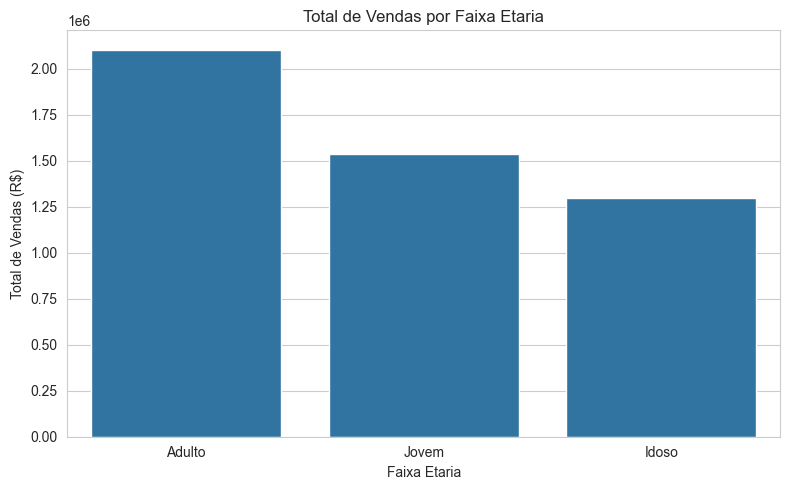

In [13]:
# Grafico de barras - total por faixa etaria
df_faixa = total_faixa.reset_index()
df_faixa.columns = ['Faixa_Etaria', 'Total_Vendas']

plt.figure(figsize=(8, 5))
sns.barplot(x='Faixa_Etaria', y='Total_Vendas', data=df_faixa)
plt.title('Total de Vendas por Faixa Etaria')
plt.xlabel('Faixa Etaria')
plt.ylabel('Total de Vendas (R$)')
plt.tight_layout()
plt.show()

## Pergunta 5
Qual é a relação entre a idade dos clientes e a categoria de produto mais vendida para cada faixa etária?

In [16]:
# Filtrar cada faixa e ver qual categoria eles mais compram
jovens  = vendas[vendas['Faixa_Etaria'] == 'Jovem']
adultos = vendas[vendas['Faixa_Etaria'] == 'Adulto']
idosos  = vendas[vendas['Faixa_Etaria'] == 'Idoso']

In [17]:
print('=== Jovens ===')
print(jovens.groupby('Categoria')['Total_Venda'].sum().sort_values(ascending=False))


=== Jovens ===
Categoria
Alimentos Frescos              415231.1493
Produtos de Mercearia          165813.2423
Produtos de Limpeza            150935.1276
Bebidas                        142194.6466
Produtos de Higiene Pessoal    141814.2220
Laticínios e Ovos              141731.5238
Pet Shop                       135276.4658
Congelados                     134152.8810
Utilidades Domésticas          110034.1187
Name: Total_Venda, dtype: float64


In [20]:
print('=== Adultos ===')
print(adultos.groupby('Categoria')['Total_Venda'].sum().sort_values(ascending=False))

=== Adultos ===
Categoria
Alimentos Frescos              588500.6163
Produtos de Mercearia          233088.2295
Pet Shop                       196751.9196
Laticínios e Ovos              194924.6674
Congelados                     190886.1754
Produtos de Higiene Pessoal    188281.7456
Produtos de Limpeza            181713.6974
Bebidas                        180797.3330
Utilidades Domésticas          147097.3817
Name: Total_Venda, dtype: float64


In [21]:
print('=== Idosos ===')
print(idosos.groupby('Categoria')['Total_Venda'].sum().sort_values(ascending=False))

=== Idosos ===
Categoria
Alimentos Frescos              361577.6914
Bebidas                        131402.1827
Produtos de Mercearia          130752.1748
Laticínios e Ovos              123304.2806
Produtos de Limpeza            114897.0305
Congelados                     114681.0767
Produtos de Higiene Pessoal    109943.5134
Pet Shop                       108303.1776
Utilidades Domésticas          102391.0762
Name: Total_Venda, dtype: float64


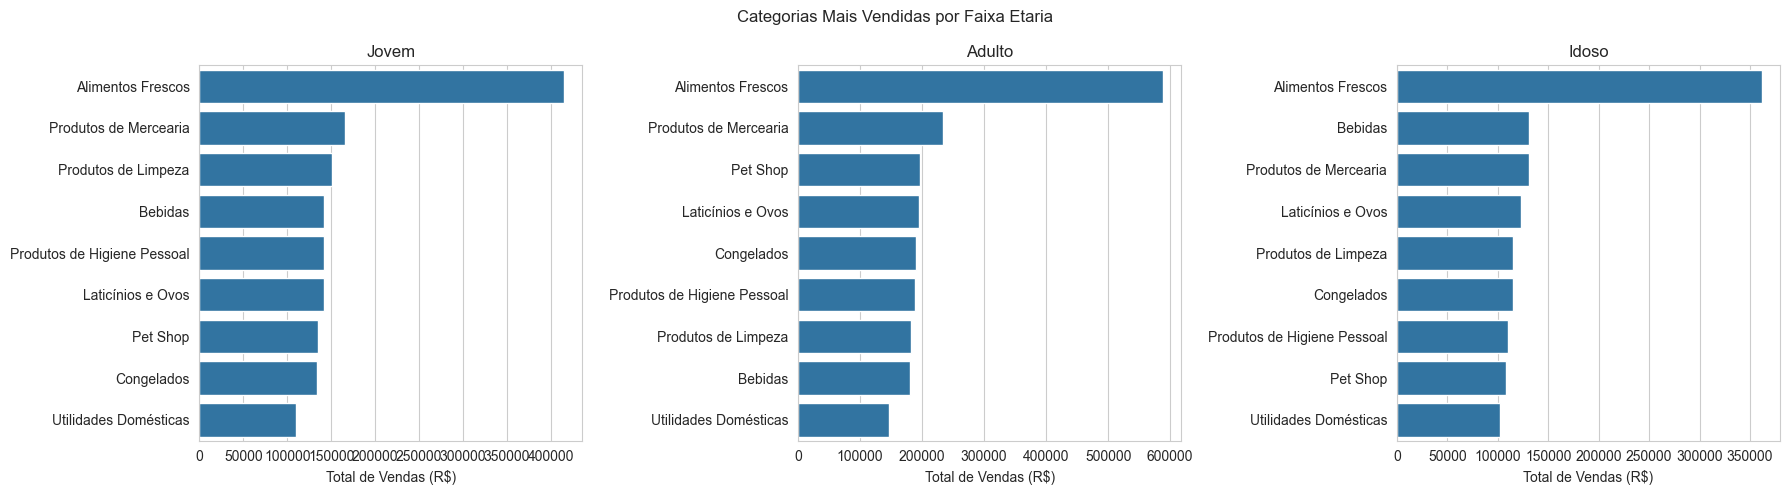

In [22]:
# Grafico de barras para cada faixa etaria
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Categorias Mais Vendidas por Faixa Etaria')

grupos = [('Jovem', jovens), ('Adulto', adultos), ('Idoso', idosos)]

for i, (nome, df_grupo) in enumerate(grupos):
    dados = df_grupo.groupby('Categoria')['Total_Venda'].sum().sort_values(ascending=False).reset_index()
    dados.columns = ['Categoria', 'Total_Vendas']
    sns.barplot(x='Total_Vendas', y='Categoria', data=dados, ax=axes[i])
    axes[i].set_title(nome)
    axes[i].set_xlabel('Total de Vendas (R$)')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

## Pergunta 6
Qual a distribuicao das vendas ao longo dos dias da semana?

In [ ]:
vendas_dia = vendas.groupby('Dia_Semana')['Total_Venda'].sum().sort_values(ascending=False)
print(vendas_dia)

In [ ]:
# Media de vendas por dia da semana
media_dia = vendas.groupby('Dia_Semana')['Total_Venda'].mean().sort_values(ascending=False).round(2)
print(media_dia)

In [ ]:
# Grafico de barras - total por dia da semana
nomes_dias = {
    'Monday': 'Segunda', 'Tuesday': 'Terca', 'Wednesday': 'Quarta',
    'Thursday': 'Quinta', 'Friday': 'Sexta', 'Saturday': 'Sabado', 'Sunday': 'Domingo'
}
vendas['Dia_PT'] = vendas['Dia_Semana'].map(nomes_dias)
vendas_dia2 = vendas.groupby('Dia_PT')['Total_Venda'].sum().sort_values(ascending=False).reset_index()
vendas_dia2.columns = ['Dia', 'Total_Vendas']

plt.figure(figsize=(10, 5))
sns.barplot(x='Dia', y='Total_Vendas', data=vendas_dia2)
plt.title('Total de Vendas por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Total de Vendas (R$)')
plt.tight_layout()
plt.show()

## Pergunta 7
Como as vendas mensais se comparam antes e durante a Black Friday?

In [ ]:
# Vendas mensais
vendas_mensais = vendas.groupby('Mes')['Total_Venda'].sum().round(2)
print(vendas_mensais)

In [ ]:
# Comparar novembro (mes da Black Friday) com os meses anteriores
novembro = vendas[vendas['Mes'] == 11]
antes_novembro = vendas[vendas['Mes'] < 11]

total_novembro = novembro['Total_Venda'].sum()
media_antes    = vendas.groupby('Mes')['Total_Venda'].sum()[antes_novembro['Mes'].unique()].mean()

print(f'Media mensal (Jan-Out): R$ {media_antes:,.2f}')
print(f'Total em Novembro (Black Friday): R$ {total_novembro:,.2f}')

In [ ]:
# Grafico de linha - evolucao das vendas mensais
nomes_meses = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
               7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'}

df_mensal = vendas_mensais.reset_index()
df_mensal.columns = ['Mes', 'Total_Vendas']
df_mensal['Nome_Mes'] = df_mensal['Mes'].map(nomes_meses)

plt.figure(figsize=(12, 5))
sns.lineplot(x='Nome_Mes', y='Total_Vendas', data=df_mensal, marker='o')
plt.title('Vendas Mensais ao Longo do Ano (Novembro = Black Friday)')
plt.xlabel('Mes')
plt.ylabel('Total de Vendas (R$)')
plt.tight_layout()
plt.show()

## Pergunta 8
Qual e o ticket medio por faixa etaria e como ele varia entre diferentes categorias?

In [ ]:
ticket = vendas.groupby(['Faixa_Etaria', 'Categoria'])['Total_Venda'].mean().round(2).reset_index()
ticket.columns = ['Faixa_Etaria', 'Categoria', 'Ticket_Medio']
ticket = ticket.sort_values(['Faixa_Etaria', 'Ticket_Medio'], ascending=[True, False])
ticket

In [ ]:
# Heatmap do ticket medio (faixa etaria x categoria)
tabela_pivot = ticket.pivot(index='Categoria', columns='Faixa_Etaria', values='Ticket_Medio')

plt.figure(figsize=(10, 8))
sns.heatmap(tabela_pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Ticket Medio por Faixa Etaria e Categoria (R$)')
plt.tight_layout()
plt.show()

## Pergunta 9
Comparando a semana da Black Friday com a do Natal, qual semana teve melhor desempenho?

In [ ]:
# Semana da Black Friday: 20 a 26 de novembro de 2023
semana_bf = vendas[(vendas['Data'] >= '2023-11-20') & (vendas['Data'] <= '2023-11-26')]

# Semana do Natal: 18 a 24 de dezembro de 2023
semana_natal = vendas[(vendas['Data'] >= '2023-12-18') & (vendas['Data'] <= '2023-12-24')]

media_bf    = semana_bf['Total_Venda'].mean().round(2)
media_natal = semana_natal['Total_Venda'].mean().round(2)

total_bf    = semana_bf['Total_Venda'].sum().round(2)
total_natal = semana_natal['Total_Venda'].sum().round(2)

print(f'Semana Black Friday - Media: R$ {media_bf} | Total: R$ {total_bf}')
print(f'Semana Natal        - Media: R$ {media_natal} | Total: R$ {total_natal}')

if total_bf > total_natal:
    print('A semana da Black Friday teve melhor desempenho.')
else:
    print('A semana do Natal teve melhor desempenho.')

In [ ]:
# Grafico comparando as duas semanas
df_comparacao = pd.DataFrame({
    'Semana': ['Black Friday (20-26/Nov)', 'Natal (18-24/Dez)'],
    'Total_Vendas': [total_bf, total_natal]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Semana', y='Total_Vendas', data=df_comparacao)
plt.title('Comparacao: Semana da Black Friday vs Semana do Natal')
plt.xlabel('')
plt.ylabel('Total de Vendas (R$)')
plt.tight_layout()
plt.show()

## Pergunta 10
Qual foi o impacto das promocoes nas vendas? Quais produtos tiveram o maior aumento?

In [ ]:
# Separar vendas com e sem desconto
com_desconto = vendas[vendas['Desconto'] > 0]
sem_desconto = vendas[vendas['Desconto'] == 0]

print(f'Transacoes sem desconto: {len(sem_desconto)}')
print(f'Media de venda sem desconto: R$ {sem_desconto["Total_Venda"].mean():.2f}')

print()
print(f'Transacoes com desconto: {len(com_desconto)}')
print(f'Media de venda com desconto: R$ {com_desconto["Total_Venda"].mean():.2f}')

In [ ]:
# Media de cada produto com desconto vs sem desconto
media_com = com_desconto.groupby('Produto')['Total_Venda'].mean().round(2)
media_sem  = sem_desconto.groupby('Produto')['Total_Venda'].mean().round(2)

comparacao = pd.DataFrame({'Com_Desconto': media_com, 'Sem_Desconto': media_sem})
comparacao = comparacao.dropna()
comparacao['Aumento'] = (comparacao['Com_Desconto'] - comparacao['Sem_Desconto']).round(2)
comparacao = comparacao.sort_values('Aumento', ascending=False)

print('Top 10 produtos com maior aumento nas vendas durante promocoes:')
comparacao.head(10)

In [ ]:
# Grafico de barras - top 10 produtos com maior aumento
top10 = comparacao.head(10).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(x='Produto', y='Aumento', data=top10)
plt.title('Top 10 Produtos com Maior Aumento de Vendas nas Promocoes')
plt.xlabel('Produto')
plt.ylabel('Aumento Medio nas Vendas (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()